# SLORTA 
* [Dashboard](https://metabase.dds.dot.ca.gov/dashboard/361-agency-split-reconciliation)
* Figuring out why the numbers change based on download
* If this is happening for other questions or just Agency Split - Settled Amount?

In [1]:
import calitp_data_analysis.magics

In [17]:
import google.auth
import pandas as pd
import numpy as np
from calitp_data_analysis.sql import to_snakecase

In [3]:
from calitp_data_analysis import get_fs
fs = get_fs()

In [4]:
import google.auth
import pandas_gbq

credentials, project = google.auth.default()
from functools import cache

from calitp_data_analysis.gcs_pandas import GCSPandas
from calitp_data_analysis.gcs_geopandas import GCSGeoPandas

In [5]:


@cache
def gcs_geopandas():
    return GCSGeoPandas()

In [6]:
@cache
def gcs_pandas():
    return GCSPandas()

In [7]:
pd.options.display.max_columns = 100
pd.options.display.float_format = "{:.2f}".format 
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

In [27]:
df_settlements = to_snakecase(pd.read_excel("gs://calitp-analytics-data/data-analyses/payments/slorta/Fct Payments Settlements.xlsx")) 
df_deposits    =  to_snakecase(pd.read_excel("gs://calitp-analytics-data/data-analyses/payments/slorta/Fct Payments Deposit Transactions.xlsx"))
df_rides       = to_snakecase(pd.read_excel("gs://calitp-analytics-data/data-analyses/payments/slorta/fct_payments_rides_v2.xlsx"))

/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [28]:
# If timestamps are strings, parse them:
df_settlements['record_updated_timestamp_utc'] = pd.to_datetime(df_settlements['record_updated_timestamp_utc'], utc=True)
df_deposits['settlement_date'] = pd.to_datetime(df_deposits['settlement_date'])
df_deposits['payment_date']    = pd.to_datetime(df_deposits['payment_date'])
df_rides['transaction_date_pacific'] = pd.to_datetime(df_rides['transaction_date_pacific'])

# ----------------------------
# 1) all_settlements (CTE A)
# ----------------------------
# Filter to good records like SQL

In [29]:
mask_good = (
    df_settlements['aggregation_id'].notna() & (df_settlements['aggregation_id'] != '') &
    df_settlements['retrieval_reference_number'].notna() & (df_settlements['retrieval_reference_number'] != '') &
    (df_settlements['settlement_type'].isin(['DEBIT', 'CREDIT'])) &
    (df_settlements['record_updated_timestamp_utc'] >= pd.Timestamp('2024-01-01', tz='UTC'))
)
st = df_settlements.loc[mask_good].copy()

# Build rrn_sales_refund_key
rrn_str = st['retrieval_reference_number'].astype(str).str.strip()
sales_refund = np.where(st['settlement_type'].eq('DEBIT'), 'Sales',
                np.where(st['settlement_type'].eq('CREDIT'), 'Refund', '_UNKNOWN'))
st['rrn_sales_refund_key'] = rrn_str + sales_refund

# Convert UTC to Pacific date (display date used in final SELECT)
# If you need a true PST conversion, use tz-localize/convert (requires pytz or zoneinfo)
st['record_updated_ts_pst'] = st['record_updated_timestamp_utc'].dt.tz_convert('America/Los_Angeles')
st['requested_for_settlement_date'] = st['record_updated_ts_pst'].dt.date  # DATE(..., 'America/Los_Angeles')

# Summarize requested_settlement_amount
grp_cols = [
    'rrn_sales_refund_key','participant_id','customer_id','aggregation_id',
    'retrieval_reference_number','settlement_type','requested_for_settlement_date','settlement_status'
]
all_settlements = (
    st.groupby(grp_cols, dropna=False, as_index=False)['transaction_amount']
      .sum()
      .rename(columns={'transaction_amount': 'requested_settlement_amount'})
)

# ----------------------------
# 2) all_deposits_raw (CTE B)
# ----------------------------
dep = df_deposits.copy()
dep['purch_id_str'] = dep['purch_id'].astype(str).str.strip()
dep['sales_refund_flag'] = np.where(dep['amount'] > 0, 'Sales',
                           np.where(dep['amount'] < 0, 'Refund', 'Zero'))
dep = dep[(dep['purch_id_str'] != '') & dep['purch_id_str'].notna()].copy()

# ----------------------------
# 3) all_deposits (aggregate to 1 row per Purch_ID + Sales/Refund) (CTE C)
# ----------------------------
dep_sr = dep[dep['sales_refund_flag'].isin(['Sales','Refund'])].copy()
dep_sr['purch_sales_refund_key'] = dep_sr['purch_id_str'] + dep_sr['sales_refund_flag']

# To make ANY_VALUE deterministic, pick settlement/payment dates after sorting
# Here we choose the max date (you can choose first after sorting if needed)
agg_funcs = {
    'amount': 'sum',
    'settlement_date': 'max',
    'payment_date': 'max'
}
all_deposits = (
    dep_sr.groupby('purch_sales_refund_key', as_index=False)
          .agg(agg_funcs)
          .rename(columns={
              'amount': 'elavon_amount',
              'settlement_date': 'elavon_settlement_date',
              'payment_date': 'elavon_payment_date'
          })
)

# ----------------------------
# 4) rides_device (latest device per aggregation) (CTE D)
# ----------------------------
# Filter by date as in SQL
rides = df_rides[df_rides['transaction_date_pacific'] > pd.Timestamp('2023-12-31')].copy()

# Sort latest first, then drop duplicates to keep the latest device per aggregation
rides_sorted = rides.sort_values(['aggregation_id', 'transaction_date_pacific'], ascending=[True, False])
rides_device = rides_sorted.drop_duplicates(subset=['aggregation_id'], keep='first')[['aggregation_id', 'device_id']]

# ----------------------------
# 5) Final JOINs (E)
# ----------------------------
# Join settlements -> deposits on concatenated keys
merged = all_settlements.merge(
    all_deposits,
    left_on='rrn_sales_refund_key',
    right_on='purch_sales_refund_key',
    how='left'
)

# Join device per aggregation
merged = merged.merge(
    rides_device,
    on='aggregation_id',
    how='left'
)

# Final projection (rename to match SQL output names)
out = merged.rename(columns={
    'participant_id': 'Participant_ID',
    'retrieval_reference_number': 'RRN',
    'settlement_type': 'Settlement_Type',
    'settlement_status': 'Settlement_Status',
    'requested_settlement_amount': 'Requested_for_Settlement_Amount',
    'purch_sales_refund_key': 'Elavon_Purch_ID_SalesRefundKey',
    'elavon_amount': 'Elavon_Amount',
    'elavon_settlement_date': 'Elavon_Settlement_Date',
    'elavon_payment_date': 'Elavon_Payment_Date',
    'device_id': 'device_id',
    'requested_for_settlement_date': 'Requested_for_Settlement_Date'
})

# Order and limit
out = out.sort_values('Requested_for_Settlement_Date', ascending=True).head(1048575)

# Now `out` mirrors the SQL output.

In [30]:
out.head()

,rrn_sales_refund_key,Participant_ID,customer_id,aggregation_id,RRN,Settlement_Type,Requested_for_Settlement_Date,Settlement_Status,Requested_for_Settlement_Amount,Elavon_Purch_ID_SalesRefundKey,Elavon_Amount,Elavon_Settlement_Date,Elavon_Payment_Date,device_id
0,7708371910496199704069Sales,slorta,7c2246a5-0228-4e6d-942a-326515169513,debd5668-ab26-48e6-bbf5-ea4d2eaf368f,7708371910496199704069,DEBIT,2026-02-11,SETTLED,1.50,7708371910496199704069Sales,1.50,2026-02-11,2026-02-12,96023
2,7708384188466248304278Sales,slorta,3ae3eeeb-afb3-40b5-9371-d75cf9ee1a55,1e61291a-9c71-46dc-bdc7-9a0a92bbef5f,7708384188466248304278,DEBIT,2026-02-11,SETTLED,4.50,7708384188466248304278Sales,4.50,2026-02-11,2026-02-12,96023
3,7708839260846952604094Sales,slorta,b6534445-a994-4628-a3ab-7311b101fc71,005e3c70-ebda-4490-a48b-e19786ea81fd,7708839260846952604094,DEBIT,2026-02-11,SETTLED,1.50,7708839260846952604094Sales,1.50,2026-02-12,2026-02-13,96025
4,7708839261876853504075Sales,slorta,3afba19b-3032-4dbb-b024-8b3290125ae3,b1a43ca8-2031-4f45-86fa-78d61c1d68c2,7708839261876853504075,DEBIT,2026-02-11,SETTLED,1.50,7708839261876853504075Sales,1.50,2026-02-12,2026-02-13,96023
5,7708839261886871804723Sales,slorta,c1e2659b-5947-4538-8fda-e0d17d129125,b85f3ce5-25a1-4b39-a8a8-d9daddbb6b3f,7708839261886871804723,DEBIT,2026-02-11,SETTLED,1.50,7708839261886871804723Sales,1.50,2026-02-12,2026-02-13,96023


In [31]:
slo_device_crosswalk_df = to_snakecase(pd.read_csv("gs://calitp-analytics-data/data-analyses/payments/slo_terminalid_2026.csv"))

In [32]:
slo_device_crosswalk_df.head(1)

,deviceidentifier,description,agency
0,97001,Bus 754,SLO City


In [36]:
m1 = pd.merge( out, slo_device_crosswalk_df, right_on = "deviceidentifier", left_on = "device_id", how = "left", indicator = True)

In [42]:
m1['ELAVON_SETTLEMENT_month'] = m1['Elavon_Settlement_Date'].dt.month

In [43]:
m1['ELAVON_PAYMENT_month'] = m1['Elavon_Payment_Date'].dt.month

In [37]:
m1.head()

,rrn_sales_refund_key,Participant_ID,customer_id,aggregation_id,RRN,Settlement_Type,Requested_for_Settlement_Date,Settlement_Status,Requested_for_Settlement_Amount,Elavon_Purch_ID_SalesRefundKey,Elavon_Amount,Elavon_Settlement_Date,Elavon_Payment_Date,device_id,deviceidentifier,description,agency,_merge
0,7708371910496199704069Sales,slorta,7c2246a5-0228-4e6d-942a-326515169513,debd5668-ab26-48e6-bbf5-ea4d2eaf368f,7708371910496199704069,DEBIT,2026-02-11,SETTLED,1.50,7708371910496199704069Sales,1.50,2026-02-11,2026-02-12,96023,96023,Bus - 1910,SLO RTA,both
1,7708384188466248304278Sales,slorta,3ae3eeeb-afb3-40b5-9371-d75cf9ee1a55,1e61291a-9c71-46dc-bdc7-9a0a92bbef5f,7708384188466248304278,DEBIT,2026-02-11,SETTLED,4.50,7708384188466248304278Sales,4.50,2026-02-11,2026-02-12,96023,96023,Bus - 1910,SLO RTA,both
2,7708839260846952604094Sales,slorta,b6534445-a994-4628-a3ab-7311b101fc71,005e3c70-ebda-4490-a48b-e19786ea81fd,7708839260846952604094,DEBIT,2026-02-11,SETTLED,1.50,7708839260846952604094Sales,1.50,2026-02-12,2026-02-13,96025,96025,Bus - 1912,SLO RTA,both
3,7708839261876853504075Sales,slorta,3afba19b-3032-4dbb-b024-8b3290125ae3,b1a43ca8-2031-4f45-86fa-78d61c1d68c2,7708839261876853504075,DEBIT,2026-02-11,SETTLED,1.50,7708839261876853504075Sales,1.50,2026-02-12,2026-02-13,96023,96023,Bus - 1910,SLO RTA,both
4,7708839261886871804723Sales,slorta,c1e2659b-5947-4538-8fda-e0d17d129125,b85f3ce5-25a1-4b39-a8a8-d9daddbb6b3f,7708839261886871804723,DEBIT,2026-02-11,SETTLED,1.50,7708839261886871804723Sales,1.50,2026-02-12,2026-02-13,96023,96023,Bus - 1910,SLO RTA,both


In [50]:
m1_debit = m1.loc[m1.Settlement_Type == "DEBIT"]

In [51]:
m1.Settlement_Type.value_counts()

Settlement_Type
DEBIT     3745
CREDIT       1
Name: count, dtype: int64

In [52]:
m1._merge.value_counts()

_merge
both          3746
left_only        0
right_only       0
Name: count, dtype: int64

In [59]:
m1.groupby(["ELAVON_PAYMENT_month"]).agg({"Elavon_Amount":"sum"})

,Elavon_Amount
ELAVON_PAYMENT_month,
2.00,70.50
3.00,114.50
4.00,110.75
5.00,2594.50
6.00,4287.75
7.00,1107.00


In [57]:
m1.groupby(["ELAVON_PAYMENT_month", "agency"]).agg({"Elavon_Amount":"sum"})

Elavon_Amount
ELAVON_PAYMENT_month agency                 
2.00                 SLO RTA           70.50
3.00                 SLO City          16.25
                     SLO RTA           98.25
4.00                 SLO City          31.25
                     SLO RTA           79.50
5.00                 SLO City         907.00
                     SLO RTA         1687.50
6.00                 SLO City         925.25
                     SLO RTA         3362.50
7.00                 SLO City         286.50
                     SLO RTA          820.50

In [58]:
m1.groupby(["ELAVON_SETTLEMENT_month"]).agg({"Elavon_Amount":"sum"})

,Elavon_Amount
ELAVON_SETTLEMENT_month,
2.00,74.50
3.00,114.00
4.00,110.75
5.00,2679.00
6.00,4385.75
7.00,921.00


In [54]:
m1.groupby(["ELAVON_SETTLEMENT_month","agency"]).agg({"Elavon_Amount":"sum"})

Elavon_Amount
ELAVON_SETTLEMENT_month agency                 
2.00                    SLO RTA           74.50
3.00                    SLO City          16.25
                        SLO RTA           97.75
4.00                    SLO City          34.75
                        SLO RTA           76.00
5.00                    SLO City         921.50
                        SLO RTA         1757.50
6.00                    SLO City         946.25
                        SLO RTA         3439.50
7.00                    SLO City         247.50
                        SLO RTA          673.50

## Charge + Nominal Amount
* [SQL Query](https://metabase.dds.dot.ca.gov/question/5545-device-id-main-sales-reconciliation-table)
* 
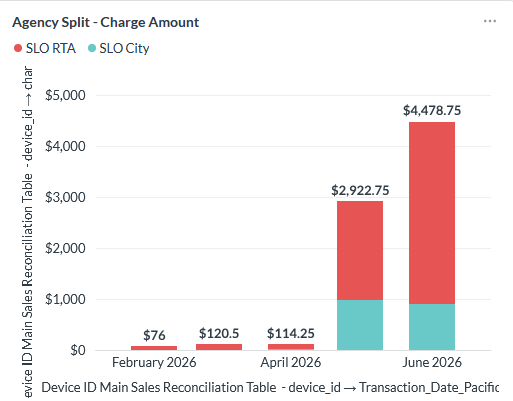 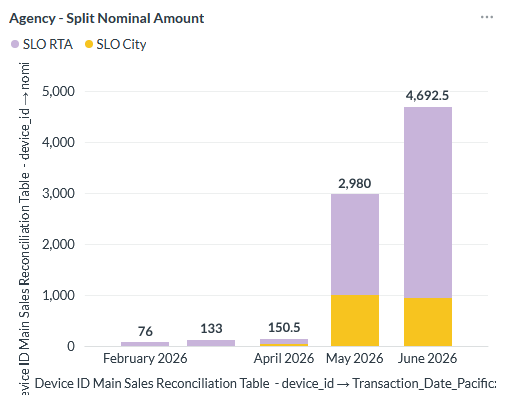

In [55]:
slo_main_sales_df = to_snakecase(pd.read_excel("gs://calitp-analytics-data/data-analyses/payments/slorta/device_id_main_sales_recon.xlsx", sheet_name = "Query result"))

FileNotFoundError: b/calitp-analytics-data/o/data-analyses%2Fpayments%2Fslorta%2Fdevice_id_main_sales_recon.xlsx

In [ ]:
slo_main_sales_df.sample()

In [ ]:
slo_main_sales_df = pd.merge(slo_main_sales_df, slo_device_crosswalk_df,  left_on = "device_id",right_on = "deviceidentifier", how = "left")

In [ ]:
slo_main_sales_df['month'] = pd.to_datetime(slo_main_sales_df['transaction_date_pacific']).dt.month

In [ ]:
slo_main_sales_df.groupby(["month"]).agg({"nominal_amt_sum":"sum", "charge_amt_sum":"sum"})

In [ ]:
slo_main_sales_df.groupby(["month","agency"]).agg({"nominal_amt_sum":"sum", "charge_amt_sum":"sum"})